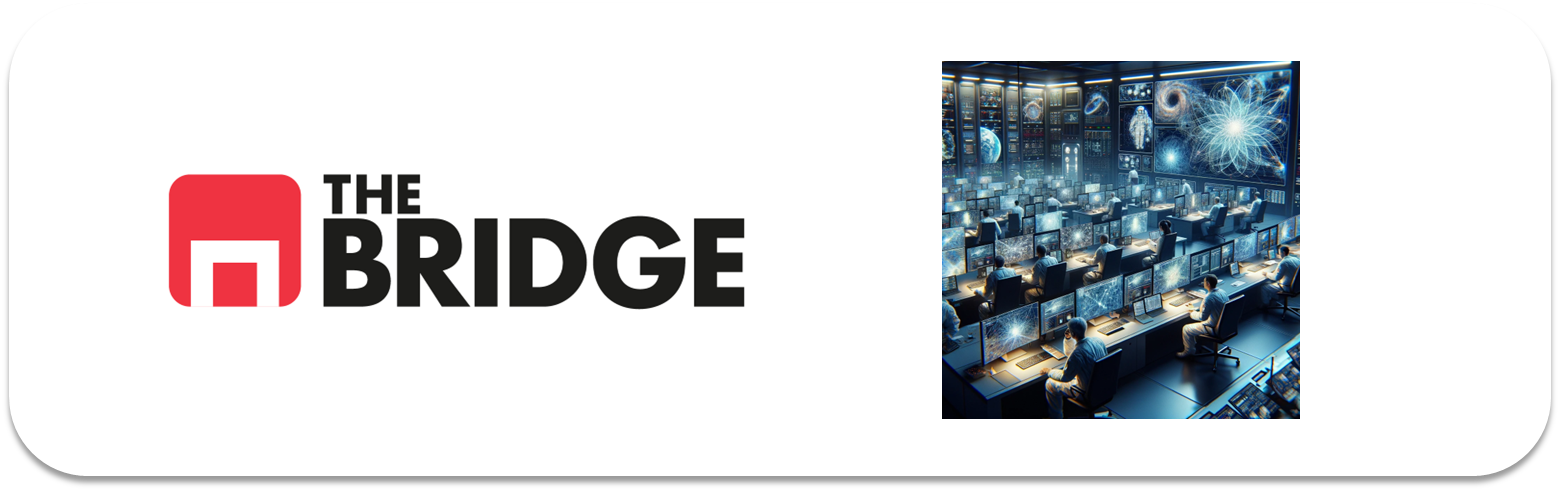

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import pandas as pd
 
RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)

### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



In [2]:
# Tras descomprimir las carpetas, ponemos sus rutas
IMG_SIZE = 160   # tamaño común para el resto del ejercicio
BATCH_SIZE = 32
 
train_dir = "./seg_train/seg_train"
test_dir = "./seg_test/seg_test"


In [3]:
train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=RANDOM_STATE,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
)
 
val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=RANDOM_STATE,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
)
 
test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False,   # para que luego y_test coincida en orden con las predicciones
)
 
class_names = train_ds.class_names
print("Clases:", class_names)
print("Nº batches train/val/test:", len(train_ds), len(val_ds), len(test_ds))


Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Clases: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Nº batches train/val/test: 351 88 94


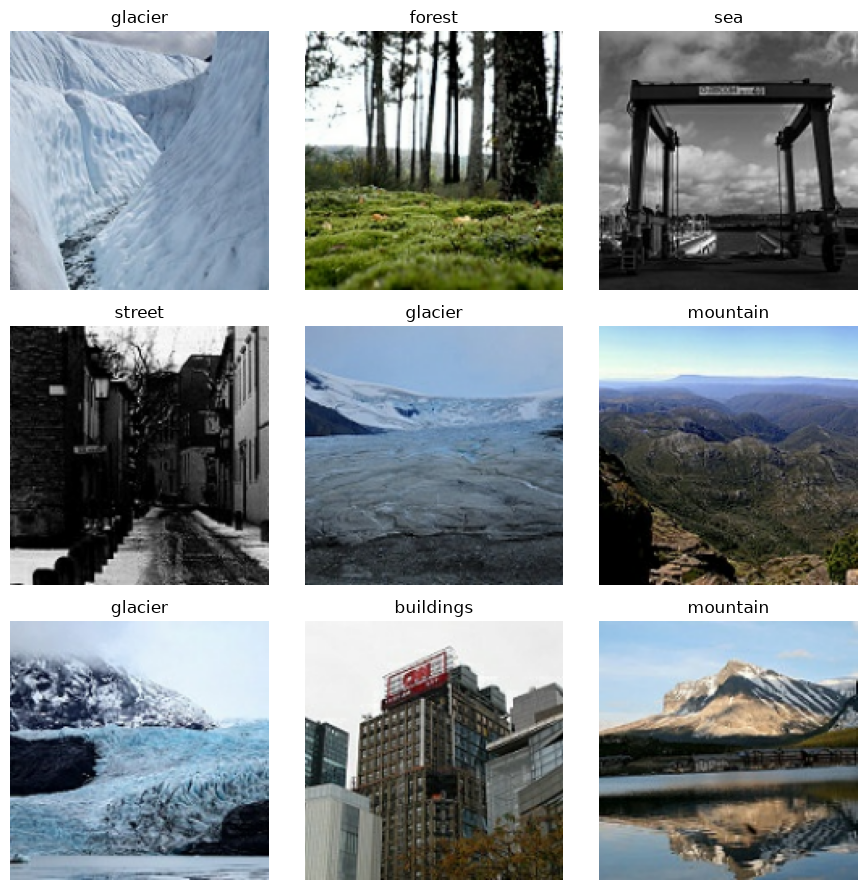

In [ ]:
# Función de visualizacion

def plot_images_from_dataset(dataset, class_names, n=9, cols=3):
    plt.figure(figsize=(3 * cols, 3 * int(np.ceil(n / cols))))
    for images, labels in dataset.take(1):
        for i in range(min(n, len(images))):
            plt.subplot(int(np.ceil(n / cols)), cols, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(class_names[labels[i]])
            plt.axis("off")
    plt.tight_layout()
    plt.show()
 
plot_images_from_dataset(train_ds, class_names, n=9)

In [5]:
# MIni-EDA
conteo_clases = {nombre: 0 for nombre in class_names}
for _, labels in train_ds.unbatch():
    conteo_clases[class_names[labels.numpy()]] += 1
print("\nDistribución de clases (train):", conteo_clases)


Distribución de clases (train): {'buildings': 1761, 'forest': 1835, 'glacier': 1931, 'mountain': 1998, 'sea': 1797, 'street': 1906}


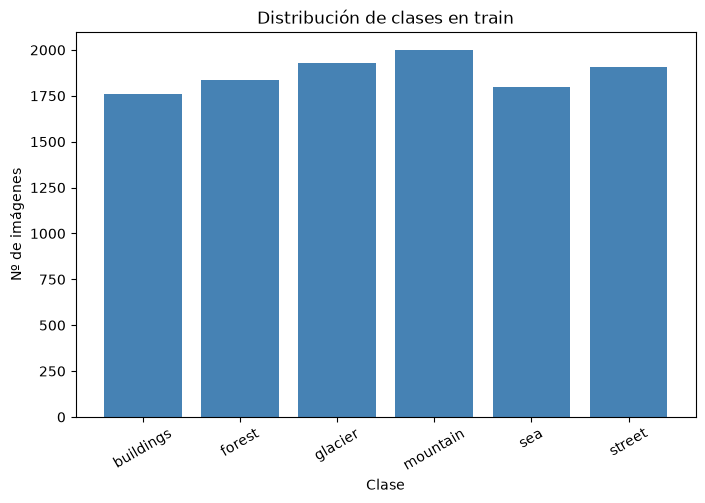

In [6]:
plt.figure(figsize=(8, 5))
plt.bar(conteo_clases.keys(), conteo_clases.values(), color="steelblue")
plt.title("Distribución de clases en train")
plt.xlabel("Clase")
plt.ylabel("Nº de imágenes")
plt.xticks(rotation=30)
plt.show()

Vemos que más o menos todas las clases están equilibradas (hay pocas diferencias)

In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [8]:
NUM_CLASSES = len(class_names) 

In [17]:
# Realizamos el preprocesado específico para MObileNetV2
# MobileNetV2 espera los píxeles escalados a [-1, 1],
# así que aplicamos su función de preprocesado propia a los 3 datasets.
def aplicar_preprocesado(imagenes, etiquetas):
    return preprocess_input(imagenes), etiquetas
 
train_ds_prep = train_ds.map(aplicar_preprocesado)
val_ds_prep = val_ds.map(aplicar_preprocesado)
test_ds_prep = test_ds.map(aplicar_preprocesado)

In [ ]:
# Instanciamos el modelo base preentrenado
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,     
    weights="imagenet",
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [11]:
# Ahora hacemos el transfer learning, el modelo base actúa como extractor
# de características ya aprendido

base_model.trainable = False

In [14]:
# Establecemos máximo de 2 capas densas ocultas y la salida
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)   # convierte el mapa de features en un vector plano
x = layers.Dense(128, activation="relu")(x)   # capa oculta 1
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu")(x)    # capa oculta 2
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)  # salida: 6 clases
 
model_transfer = keras.Model(inputs, outputs)
model_transfer.summary()
 
model_transfer.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",   # las labels son enteros (0-5), no one-hot
    metrics=["accuracy"],
)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,430,598 (9.27 MB)

 Trainable params: 172,614 (674.27 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/20


c:\Users\sandy\Documents\GitHub\Bridge-sgusmar\venv_tf\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 51s 137ms/step - accuracy: 0.8638 - loss: 0.3711 - val_accuracy: 0.9088 - val_loss: 0.2439
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 46s 131ms/step - accuracy: 0.9085 - loss: 0.2455 - val_accuracy: 0.9134 - val_loss: 0.2217
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 51s 144ms/step - accuracy: 0.9259 - loss: 0.1994 - val_accuracy: 0.9177 - val_loss: 0.2232
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 51s 145ms/step - accuracy: 0.9333 - loss: 0.1787 - val_accuracy: 0.9187 - val_loss: 0.2239
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 50s 141ms/step - accuracy: 0.9417 - loss: 0.1580 - val_accuracy: 0.9241 - val_loss: 0.2319
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 52s 148ms/step - accuracy: 0.9452 - loss: 0.1440 - val_accuracy: 0.9237 - val_loss: 0.2368
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 54s 153ms/step - accuracy: 0.9523 - loss: 0.1263 - val_accuracy: 0.9234 - val_loss: 0.2449


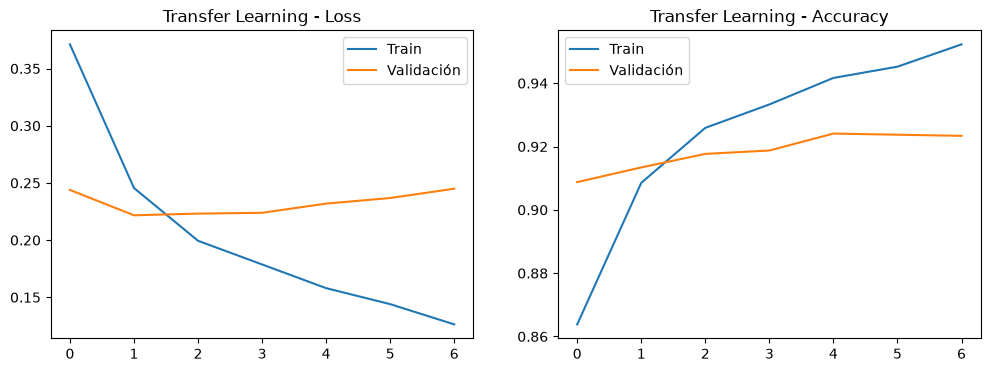

In [15]:
# Entrenamiento (incluyendo EarlyStopping)
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)
 
history_transfer = model_transfer.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=20,
    callbacks=[early_stopping],
)
 
# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_transfer.history["loss"], label="Train")
axes[0].plot(history_transfer.history["val_loss"], label="Validación")
axes[0].set_title("Transfer Learning - Loss")
axes[0].legend()
axes[1].plot(history_transfer.history["accuracy"], label="Train")
axes[1].plot(history_transfer.history["val_accuracy"], label="Validación")
axes[1].set_title("Transfer Learning - Accuracy")
axes[1].legend()
plt.show()


94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step

=== Transfer Learning: Classification Report ===
              precision    recall  f1-score   support

   buildings       0.95      0.89      0.92       437
      forest       0.98      1.00      0.99       474
     glacier       0.88      0.81      0.84       553
    mountain       0.85      0.88      0.86       525
         sea       0.93      0.98      0.95       510
      street       0.92      0.95      0.93       501

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.91      0.92      0.91      3000



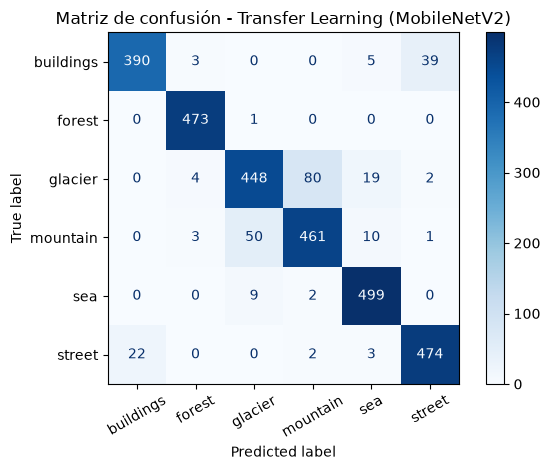


Accuracy en test (Transfer Learning): 0.9150


In [16]:
y_test = np.concatenate([y for _, y in test_ds_prep], axis=0)
y_pred_probs = model_transfer.predict(test_ds_prep)
y_pred = np.argmax(y_pred_probs, axis=1)
 
print("\n=== Transfer Learning: Classification Report ===")
print(classification_report(y_test, y_pred, target_names=class_names))
 
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap="Blues", xticks_rotation=30)
plt.title("Matriz de confusión - Transfer Learning (MobileNetV2)")
plt.tight_layout()
plt.show()
 
# Guardamos el accuracy para la comparación final del paso 6
test_acc_transfer = (y_pred == y_test).mean()
print(f"\nAccuracy en test (Transfer Learning): {test_acc_transfer:.4f}")


Pasamos a hacer Fine Tunning

In [19]:
base_model.trainable = True
FINE_TUNE_AT = len(base_model.layers) - 30   # las últimas 30 capas sí se entrenan

for capa in base_model.layers[:FINE_TUNE_AT]:
    capa.trainable = False
 
print(f"Capas entrenables del base_model: "
      f"{sum(c.trainable for c in base_model.layers)} de {len(base_model.layers)}")

Capas entrenables del base_model: 30 de 154


In [20]:
# Recompilammos con bajo learning rate

model_transfer.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # mucho más bajo que el 1e-3 por defecto
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)


Epoch 1/15


c:\Users\sandy\Documents\GitHub\Bridge-sgusmar\venv_tf\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 63s 164ms/step - accuracy: 0.8594 - loss: 0.3922 - val_accuracy: 0.9166 - val_loss: 0.2338
Epoch 2/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 64s 182ms/step - accuracy: 0.9023 - loss: 0.2702 - val_accuracy: 0.9180 - val_loss: 0.2284
Epoch 3/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 66s 188ms/step - accuracy: 0.9158 - loss: 0.2284 - val_accuracy: 0.9227 - val_loss: 0.2219
Epoch 4/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 67s 192ms/step - accuracy: 0.9270 - loss: 0.1974 - val_accuracy: 0.9223 - val_loss: 0.2142
Epoch 5/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 63s 178ms/step - accuracy: 0.9338 - loss: 0.1862 - val_accuracy: 0.9237 - val_loss: 0.2107
Epoch 6/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 60s 172ms/step - accuracy: 0.9439 - loss: 0.1611 - val_accuracy: 0.9269 - val_loss: 0.2111
Epoch 7/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 63s 180ms/step - accuracy: 0.9468 - loss: 0.1445 - val_accuracy: 0.9269 - val_loss: 0.2100
Epoch 8/15
351/351 ━━━━━━━━━━━━━━━━━━━━ 66s 187ms/step - accuracy: 0.9526 - loss: 0.1348 - val

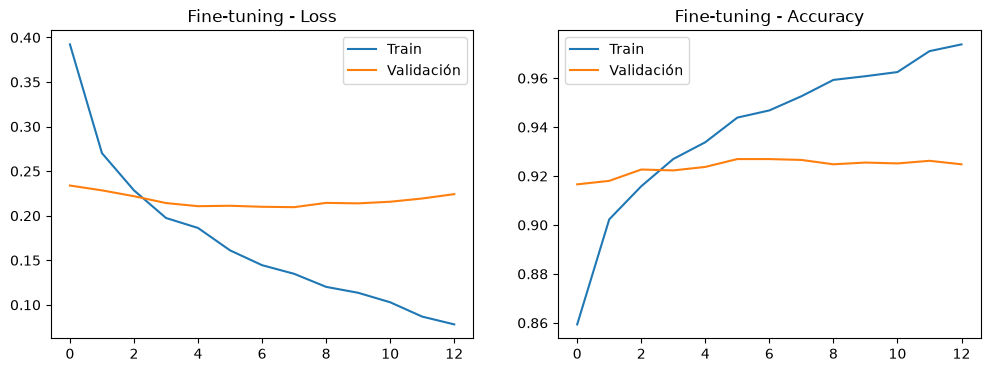

In [21]:
early_stopping_ft = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)
 
history_finetune = model_transfer.fit(
    train_ds_prep,
    validation_data=val_ds_prep,
    epochs=15,
    callbacks=[early_stopping_ft],
)
 
# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_finetune.history["loss"], label="Train")
axes[0].plot(history_finetune.history["val_loss"], label="Validación")
axes[0].set_title("Fine-tuning - Loss")
axes[0].legend()
axes[1].plot(history_finetune.history["accuracy"], label="Train")
axes[1].plot(history_finetune.history["val_accuracy"], label="Validación")
axes[1].set_title("Fine-tuning - Accuracy")
axes[1].legend()
plt.show()


94/94 ━━━━━━━━━━━━━━━━━━━━ 13s 122ms/step

=== Fine-tuning: Classification Report ===
              precision    recall  f1-score   support

   buildings       0.93      0.92      0.92       437
      forest       0.97      1.00      0.98       474
     glacier       0.87      0.84      0.86       553
    mountain       0.86      0.86      0.86       525
         sea       0.95      0.97      0.96       510
      street       0.93      0.93      0.93       501

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



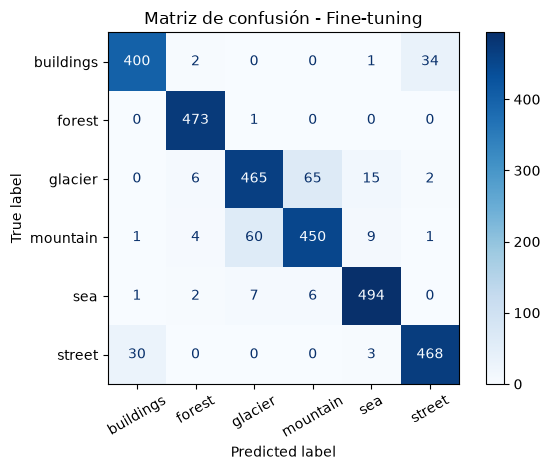


Accuracy en test (Fine-tuning): 0.9167


In [22]:
y_test_ft = np.concatenate([y for _, y in test_ds_prep], axis=0)
y_pred_probs_ft = model_transfer.predict(test_ds_prep)
y_pred_ft = np.argmax(y_pred_probs_ft, axis=1)
 
print("\n=== Fine-tuning: Classification Report ===")
print(classification_report(y_test_ft, y_pred_ft, target_names=class_names))
 
cm_ft = confusion_matrix(y_test_ft, y_pred_ft)
ConfusionMatrixDisplay(cm_ft, display_labels=class_names).plot(cmap="Blues", xticks_rotation=30)
plt.title("Matriz de confusión - Fine-tuning")
plt.tight_layout()
plt.show()
 
test_acc_finetune = (y_pred_ft == y_test_ft).mean()
print(f"\nAccuracy en test (Fine-tuning): {test_acc_finetune:.4f}")


En el último paso, vamos a replicar la CNN que hicimos en el ejercicio de workout

In [23]:
# Normalizamos de manera normal las imágenes, entre 0 y 1
def normalizar(imagenes, etiquetas):
    return imagenes / 255, etiquetas

train_ds_cnn = train_ds.map(normalizar)
val_ds_cnn = val_ds.map(normalizar)
test_ds_cnn = test_ds.map(normalizar)

In [24]:
model_cnn = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax"),  # 6 clases -> softmax
])

model_cnn.summary()

model_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

c:\Users\sandy\Documents\GitHub\Bridge-sgusmar\venv_tf\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 92416)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │    11,829,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,849,542 (45.20 MB)

 Trainable params: 11,849,542 (45.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20


c:\Users\sandy\Documents\GitHub\Bridge-sgusmar\venv_tf\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


351/351 ━━━━━━━━━━━━━━━━━━━━ 50s 140ms/step - accuracy: 0.5454 - loss: 1.1909 - val_accuracy: 0.6928 - val_loss: 0.8172
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 48s 136ms/step - accuracy: 0.7180 - loss: 0.7809 - val_accuracy: 0.7363 - val_loss: 0.7394
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 48s 136ms/step - accuracy: 0.7779 - loss: 0.6146 - val_accuracy: 0.7594 - val_loss: 0.6904
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 48s 137ms/step - accuracy: 0.8343 - loss: 0.4550 - val_accuracy: 0.7648 - val_loss: 0.7393
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 49s 139ms/step - accuracy: 0.8839 - loss: 0.3253 - val_accuracy: 0.7701 - val_loss: 0.7966
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 48s 137ms/step - accuracy: 0.9109 - loss: 0.2428 - val_accuracy: 0.7790 - val_loss: 0.8662
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 44s 126ms/step - accuracy: 0.9352 - loss: 0.1882 - val_accuracy: 0.7741 - val_loss: 0.9272
Epoch 8/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 37s 105ms/step - accuracy: 0.9479 - loss: 0.1430 - val

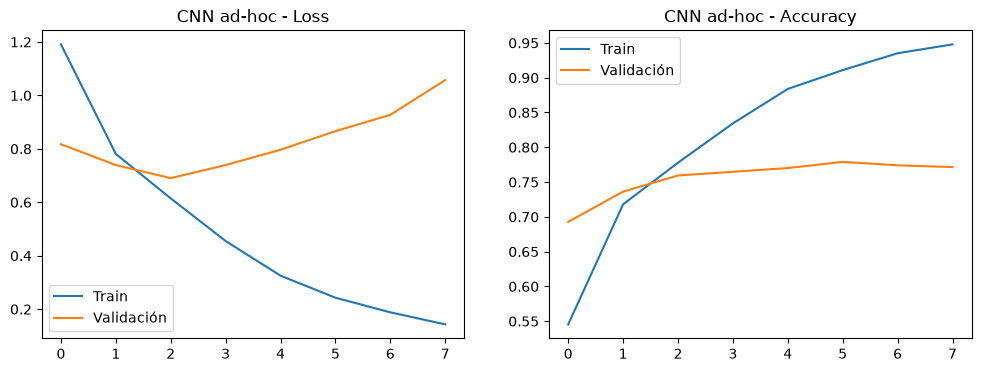

In [25]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history_cnn = model_cnn.fit(
    train_ds_cnn,
    validation_data=val_ds_cnn,
    epochs=20,
    callbacks=[early_stopping],
)

# Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_cnn.history["loss"], label="Train")
axes[0].plot(history_cnn.history["val_loss"], label="Validación")
axes[0].set_title("CNN ad-hoc - Loss")
axes[0].legend()
axes[1].plot(history_cnn.history["accuracy"], label="Train")
axes[1].plot(history_cnn.history["val_accuracy"], label="Validación")
axes[1].set_title("CNN ad-hoc - Accuracy")
axes[1].legend()
plt.show()

94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step

=== CNN ad-hoc: Classification Report ===
              precision    recall  f1-score   support

   buildings       0.71      0.76      0.74       437
      forest       0.97      0.81      0.88       474
     glacier       0.77      0.74      0.75       553
    mountain       0.79      0.62      0.70       525
         sea       0.65      0.81      0.72       510
      street       0.74      0.83      0.78       501

    accuracy                           0.76      3000
   macro avg       0.77      0.76      0.76      3000
weighted avg       0.77      0.76      0.76      3000



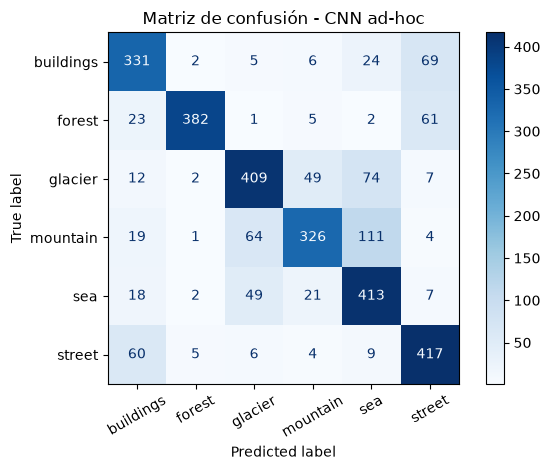


Accuracy en test (CNN ad-hoc): 0.7593


In [26]:
y_test_cnn = np.concatenate([y for _, y in test_ds_cnn], axis=0)
y_pred_probs_cnn = model_cnn.predict(test_ds_cnn)
y_pred_cnn = np.argmax(y_pred_probs_cnn, axis=1)

print("\n=== CNN ad-hoc: Classification Report ===")
print(classification_report(y_test_cnn, y_pred_cnn, target_names=class_names))

cm_cnn = confusion_matrix(y_test_cnn, y_pred_cnn)
ConfusionMatrixDisplay(cm_cnn, display_labels=class_names).plot(cmap="Blues", xticks_rotation=30)
plt.title("Matriz de confusión - CNN ad-hoc")
plt.tight_layout()
plt.show()

test_acc_cnn = (y_pred_cnn == y_test_cnn).mean()
print(f"\nAccuracy en test (CNN ad-hoc): {test_acc_cnn:.4f}")

In [ ]:
report_cnn = classification_report(y_test_cnn, y_pred_cnn, output_dict=True)
report_transfer = classification_report(y_test, y_pred, output_dict=True)
report_finetune = classification_report(y_test_ft, y_pred_ft, output_dict=True)

In [34]:
comparacion_final = pd.DataFrame([
    {
        "modelo": "CNN",
        "accuracy": test_acc_cnn,
        "precision_macro": report_cnn["macro avg"]["precision"],
        "recall_macro": report_cnn["macro avg"]["recall"],
        "f1_macro": report_cnn["macro avg"]["f1-score"]
    },
    {
        "modelo": "Transfer Learning (MobileNetV2)",
        "accuracy": test_acc_transfer,
        "precision_macro": report_transfer["macro avg"]["precision"],
        "recall_macro": report_transfer["macro avg"]["recall"],
        "f1_macro": report_transfer["macro avg"]["f1-score"]
    },
    {
        "modelo": "Fine-tuning (MobileNetV2)",
        "accuracy": test_acc_finetune,
        "precision_macro": report_finetune["macro avg"]["precision"],
        "recall_macro": report_finetune["macro avg"]["recall"],
        "f1_macro": report_finetune["macro avg"]["f1-score"]
    },
])
 
print(comparacion_final.round(4))


                            modelo  accuracy  precision_macro  recall_macro  \
0                              CNN    0.7593           0.7723        0.7610   
1  Transfer Learning (MobileNetV2)    0.9150           0.9172        0.9172   
2        Fine-tuning (MobileNetV2)    0.9167           0.9177        0.9190   

   f1_macro  
0    0.7616  
1    0.9166  
2    0.9183  


Vemos que se mejora sustancialmente con transfer learning y fine tunning prácticamente todas las métricas. Esto puede deberse a que CNN entrenada desde cero tiene que aprender toas las caracterñisticas de las imágenes a partir solo de los datos disponibles, mientras que en los otros casos se parte o de un dataset mucho más grande (ImageNet) o se permite reajustar los pesos de la red para adaptarlos al nuevo conjunto de imágenes (Fine-Tuning).